# Sparse Koopman Operators and Worst-Case Reconstruction

This notebook builds on the encode → Koopman step → decode workflow from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb). Here, sparsity and
worst-case terms regularize the learned operator.

This notebook uses two **power-user** training terms from `koopman_graph.losses`:

- `KoopmanSparsityLoss` — element-wise $L_1$ (or smoothed $L_p$, $p<1$) on the
  latent operator. Ordinary models penalize `koopman.matrix`; networked
  `koopman="graph"` models penalize **`K_self` and `K_nbr` parameters only**.
- `WorstCaseReconstructionLoss` — max-over-nodes MSE (batch $L_\infty$-style
  emphasis on hard nodes). This is a **robust training term**, not a PAC /
  $L_\infty$ / generalization certificate.

### Caveats: interpretability (read first)

- Sparse latent $K$ is **not** a sparse physical adjacency matrix.
- For graph operators, parameter sparsity on $K_{\mathrm{self}}/K_{\mathrm{nbr}}$ is
  **not** sparsity of the topology-bound effective operator
  $I\otimes K_{\mathrm{self}} + \hat{A}\otimes K_{\mathrm{nbr}}$.
- SINDy-style sparse regression (Brunton, Proctor & Kutz, 2016) identifies
  sparse ODEs in chosen observables; here the penalty is a soft regularizer
  on learned Koopman factors, not an automatic governing-equation discovery
  pipeline in node coordinates.

Enable the terms with `LossWeights(sparsity=..., worst_case=...)`. They are
**not** on the root `koopman_graph` façade.


## Method: sparsity sweep and worst-case comparison

Sweep a sparsity weight on latent $K$, report the **near-zero fraction**
($|K_{ij}| < 10^{-2}$) alongside reconstruction error, then compare sparse fits
**with and without** a worst-case reconstruction term.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark
from koopman_graph.losses import KoopmanSparsityLoss, WorstCaseReconstructionLoss
from koopman_graph.training import LossWeights

IS_CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))

# Reproducibility
DATA_SEED = 42
MODEL_SEED = 0
WC_SEED = 1
random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)

# Shared path-graph sequence
NUM_NODES = 8
NUM_TIMESTEPS = 16 if IS_CI else 24
IN_CHANNELS = 3
TOPOLOGY = "path"

sequence = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=NUM_NODES,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=IN_CHANNELS,
    topology=TOPOLOGY,
    seed=DATA_SEED,
)

# Model / training hyperparameters
HIDDEN = 16
LATENT = 8
TIME_STEP = 0.1
LR = 5e-2
EPOCHS = 12 if IS_CI else 40
WC_EPOCHS = 8 if IS_CI else 20
SPARSITY_WEIGHTS = [0.0, 0.5, 2.0]
NEAR_ZERO_THRESHOLD = 1e-2
WC_SPARSITY = 0.25
WC_WEIGHT = 0.1

print(
    f"sequence: nodes={sequence.num_nodes}, "
    f"timesteps={sequence.num_timesteps}, "
    f"in_channels={sequence.in_channels}"
)


sequence: nodes=8, timesteps=24, in_channels=3


## Helper functions

Notebook-local helpers used below.


In [2]:
def sparsity_fraction(
    matrix: torch.Tensor,
    threshold: float = NEAR_ZERO_THRESHOLD,
) -> float:
    """Fraction of entries with absolute value below ``threshold`` (near-zero)."""
    return float((matrix.detach().abs() < threshold).float().mean().item())


def make_model() -> GraphKoopmanModel:
    return GraphKoopmanModel(
        encoder=GNNEncoder(
            in_channels=IN_CHANNELS,
            hidden_channels=HIDDEN,
            latent_dim=LATENT,
        ),
        decoder=GNNDecoder(
            latent_dim=LATENT,
            hidden_channels=HIDDEN,
            out_channels=IN_CHANNELS,
        ),
        latent_dim=LATENT,
        time_step=TIME_STEP,
    )


## Train: sparsity weight sweep

Fit ordinary (dense $K$) operators across sparsity weights. Higher weight should
raise the near-zero fraction; reconstruction error typically rises as $K$ is
pushed toward sparsity.


sparsity=0: near_zero_frac(|K|<0.01)=0.047, final recon=0.0037, final L_sp=0.0000
sparsity=0.5: near_zero_frac(|K|<0.01)=0.516, final recon=0.0052, final L_sp=0.0175
sparsity=2: near_zero_frac(|K|<0.01)=0.594, final recon=0.0104, final L_sp=0.0119


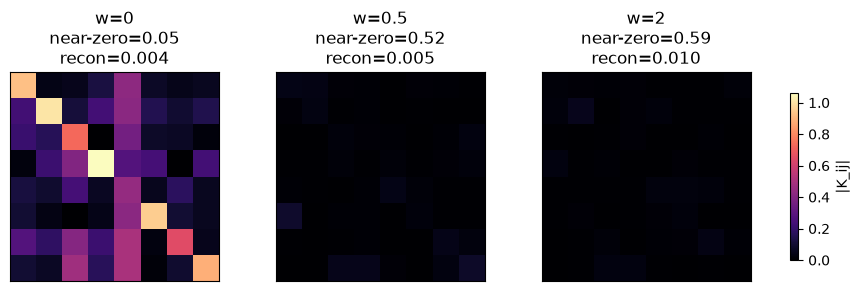

In [3]:
fractions: list[float] = []
recon_finals: list[float] = []
matrices: list[torch.Tensor] = []

for sparsity_w in SPARSITY_WEIGHTS:
    torch.manual_seed(MODEL_SEED)
    model = make_model()
    history = model.fit(
        sequence,
        epochs=EPOCHS,
        lr=LR,
        loss_weights=LossWeights(reconstruction=1.0, sparsity=sparsity_w),
    )
    k = model.koopman.matrix.detach().cpu()
    frac = sparsity_fraction(k)
    recon = float(history.reconstruction_loss[-1])
    fractions.append(frac)
    recon_finals.append(recon)
    matrices.append(k)
    print(
        f"sparsity={sparsity_w:g}: "
        f"near_zero_frac(|K|<{NEAR_ZERO_THRESHOLD:g})={frac:.3f}, "
        f"final recon={recon:.4f}, "
        f"final L_sp={history.sparsity_loss[-1]:.4f}"
    )

assert fractions[0] < fractions[-1], "higher sparsity weight should sparsify K"

# Shared color scale so |K_ij| intensities are comparable across panels.
abs_mats = [k.abs().numpy() for k in matrices]
vmax = max(float(m.max()) for m in abs_mats)

fig, axes = plt.subplots(
    1, len(SPARSITY_WEIGHTS), figsize=(9, 2.8), constrained_layout=True
)
for ax, w, m, frac, recon in zip(
    axes, SPARSITY_WEIGHTS, abs_mats, fractions, recon_finals
):
    im = ax.imshow(m, cmap="magma", vmin=0.0, vmax=vmax)
    ax.set_title(f"w={w:g}\nnear-zero={frac:.2f}\nrecon={recon:.3f}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="|K_ij|")
plt.show()


## Evaluate: with vs without worst-case term

Hold sparsity fixed and compare otherwise identical fits with
`worst_case=0` vs `worst_case>0`. The worst-case term is optional robust
training; keep claims empirical.


In [4]:
wc_histories = {}
wc_models = {}

for label, worst_case_w in (("without", 0.0), ("with", WC_WEIGHT)):
    torch.manual_seed(WC_SEED)
    model_wc = make_model()
    history_wc = model_wc.fit(
        sequence,
        epochs=WC_EPOCHS,
        lr=LR,
        loss_weights=LossWeights(
            reconstruction=1.0,
            sparsity=WC_SPARSITY,
            worst_case=worst_case_w,
        ),
    )
    wc_histories[label] = history_wc
    wc_models[label] = model_wc
    print(
        f"{label} worst_case={worst_case_w:g}: "
        f"recon={history_wc.reconstruction_loss[-1]:.4f}, "
        f"sparsity={history_wc.sparsity_loss[-1]:.4f}, "
        f"worst_case={history_wc.worst_case_loss[-1]:.4f}"
    )

assert wc_histories["with"].worst_case_loss[-1] >= 0.0
assert wc_histories["without"].worst_case_loss[-1] == 0.0

# Standalone power-user checks on the with-worst-case fit (ordinary dense K).
# FitHistory stores the pre-step epoch value; post-fit KoopmanSparsityLoss
# can differ slightly after the final optimizer update.
model_with = wc_models["with"]
sp = KoopmanSparsityLoss()(model_with.koopman)
print(f"standalone KoopmanSparsityLoss (with)={float(sp.detach()):.4f}")

model_with.eval()
with torch.no_grad():
    pred = model_with(sequence[0])
    wc_one_pair = WorstCaseReconstructionLoss()(pred, sequence[1].x)
print(f"standalone WorstCaseReconstructionLoss (one pair)={float(wc_one_pair):.4f}")


without worst_case=0: recon=0.0072, sparsity=0.0485, worst_case=0.0000
with worst_case=0.1: recon=0.0077, sparsity=0.0569, worst_case=0.0166
standalone KoopmanSparsityLoss (with)=0.0530
standalone WorstCaseReconstructionLoss (one pair)=0.2276


## Takeaways

1. Raise `LossWeights.sparsity` to encourage sparse latent operators; watch the
   near-zero fraction of $K$ against reconstruction error.
2. When using `koopman="graph"`, inspect `K_self` / `K_nbr` — not
   `effective_matrix` — when interpreting the sparsity target (this notebook
   uses ordinary dense $K$).
3. `worst_case` is optional robust training; compare with/without empirically
   and keep claims short of generalization certificates.
4. Import sparsity / worst-case helpers from `koopman_graph.losses`.

## Next steps

- See [`08_loss_stability.ipynb`](08_loss_stability.ipynb) for other operator regularizers.
- See [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb) to inspect the learned spectrum.
- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the base workflow.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
